<a href="https://colab.research.google.com/github/Charanca24/Data-science-Project/blob/main/Updated_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project Title: Detecting Healthcare Provider Fraud Using Aggregated Claims Analysis**
**Project Brief**
In this project, I aim to develop a robust machine learning system to detect potential fraudulent activities among healthcare providers. By analyzing simulated Medicare claims data, I will build features that capture billing patterns and use supervised learning to classify providers.

**Dataset Description**
I am using the "Healthcare Provider Fraud Detection Analysis" dataset from Mendeley Data. This is a relational dataset consisting of:

Inpatient Data: Records of claims for patients admitted to hospitals.

Outpatient Data: Records of claims for visits not requiring hospital stay.

Beneficiary Data: Patient-level demographics and health conditions.

Train Labels: The ground truth indicating whether a Provider is flagged for "Potential Fraud".

# **Data Acquisition and Library Imports**
In this step, I will import all necessary Python libraries for data manipulation, visualization, and machine learning. I will also download and extract the dataset from the provided Mendeley URL.

In [1]:
import os
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# Download the dataset
url = "https://data.mendeley.com/public-api/zip/gsn2hyty37/download/1"
r = requests.get(url)
with open("fraud_data.zip", "wb") as f:
    f.write(r.content)

# Unzip the files
with zipfile.ZipFile("fraud_data.zip", "r") as zip_ref:
    zip_ref.extractall("healthcare_fraud_data")

# Load the primary files using the specified paths
path = "/content/healthcare_fraud_data/HEALTHCARE PROVIDER FRAUD DETECTION ANALYSIS/"
train_labels = pd.read_csv(path + 'Train.csv')
inpatient = pd.read_csv(path + 'Train_Inpatientdata.csv')
outpatient = pd.read_csv(path + 'Train_Outpatientdata.csv')

print("Files Loaded Successfully.")

Files Loaded Successfully.


## **Extensive Exploratory Data Analysis (EDA)**
I will now explore the dataset to understand the distribution of fraud labels, analyze claim amounts, and visualize the relationships between different variables. This helps me identify the class imbalance and patterns in billing behavior.

/tmp/ipykernel_168/731202866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PotentialFraud', data=train_labels, palette='magma')


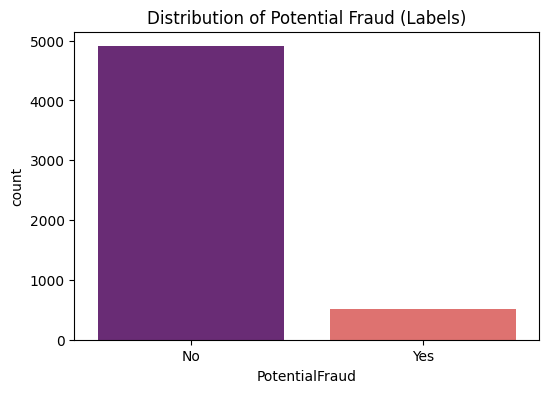

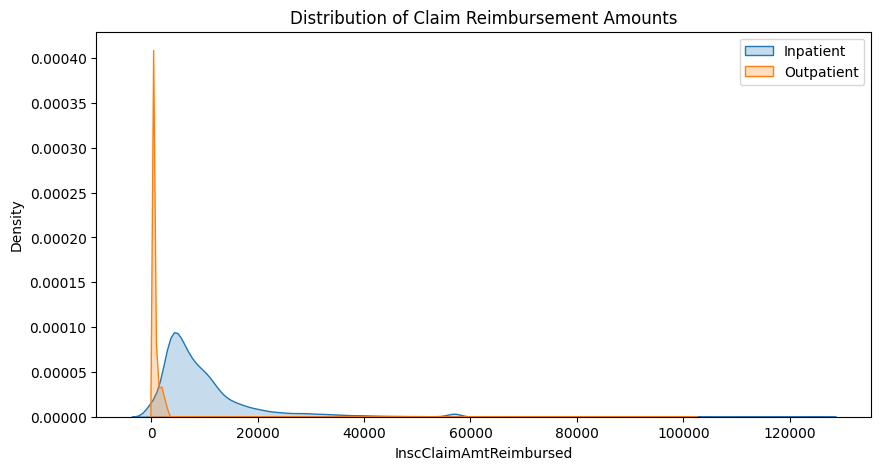

Missing values in Inpatient data:
 344003
Missing values in Outpatient data:
 8093719
Non-Fraud: 90.65%
Potential Fraud: 9.35%


In [2]:
# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='PotentialFraud', data=train_labels, palette='magma')
plt.title('Distribution of Potential Fraud (Labels)')
plt.show()

# 2. Claim Amount Distribution (Inpatient vs Outpatient)
plt.figure(figsize=(10, 5))
sns.kdeplot(inpatient['InscClaimAmtReimbursed'].dropna(), label='Inpatient', fill=True)
sns.kdeplot(outpatient['InscClaimAmtReimbursed'].dropna(), label='Outpatient', fill=True)
plt.title('Distribution of Claim Reimbursement Amounts')
plt.legend()
plt.show()

# 3. Missing Value Analysis
print("Missing values in Inpatient data:\n", inpatient.isnull().sum().sum())
print("Missing values in Outpatient data:\n", outpatient.isnull().sum().sum())

# 4. Class Imbalance Percentage
imbalance = train_labels['PotentialFraud'].value_counts(normalize=True) * 100
print(f"Non-Fraud: {imbalance['No']:.2f}%")
print(f"Potential Fraud: {imbalance['Yes']:.2f}%")

# **Preprocessing and Feature Engineering**
I am aggregating the claim-level records into provider-level features. Since the fraud labels are per-provider, I must summarize the financial and operational behavior of each provider to create a dataset suitable for classification.

In [3]:
# Combine Inpatient and Outpatient claims
all_claims = pd.concat([inpatient, outpatient], axis=0)

# Fill missing numerical values in the combined claims first
all_claims['InscClaimAmtReimbursed'] = all_claims['InscClaimAmtReimbursed'].fillna(0)
all_claims['DeductibleAmtPaid'] = all_claims['DeductibleAmtPaid'].fillna(0)

# Aggregate to Provider Level
provider_features = all_claims.groupby('Provider').agg({
    'InscClaimAmtReimbursed': ['mean', 'sum'],
    'DeductibleAmtPaid': ['mean', 'sum'],
    'BeneID': 'nunique',
    'ClaimID': 'count'
}).reset_index()

# Flatten column names
provider_features.columns = ['Provider', 'AvgReimbursement', 'TotalReimbursement',
                             'AvgDeductible', 'TotalDeductible', 'UniqueBeneficiaries', 'TotalClaims']

# Merge with Labels
df = pd.merge(train_labels, provider_features, on='Provider', how='inner')
df['PotentialFraud'] = df['PotentialFraud'].map({'Yes': 1, 'No': 0})

# FIX: Handling any remaining NaNs in aggregated columns using direct assignment
# This replaces the old .fillna(inplace=True) approach
df['AvgReimbursement'] = df['AvgReimbursement'].fillna(df['AvgReimbursement'].mean())
df['AvgDeductible'] = df['AvgDeductible'].fillna(df['AvgDeductible'].mean())

# Prepare X and y
X = df.drop(['Provider', 'PotentialFraud'], axis=1)
y = df['PotentialFraud']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dataset ready without warnings. Shape: {df.shape}")

Dataset ready without warnings. Shape: (5410, 8)


# **Final Dataset Exploration**
Before I begin the training process, I must explore the final processed dataset (df). This step ensures that the feature engineering was successful, checks for any remaining null values, and provides a statistical overview of the features like TotalReimbursement and UniqueBeneficiaries. I will also check the correlation matrix to see how the features relate to the PotentialFraud label.

--- Final Dataset Header ---


,Provider,PotentialFraud,AvgReimbursement,TotalReimbursement,AvgDeductible,TotalDeductible,UniqueBeneficiaries,TotalClaims
0,PRV51001,0,4185.600000,104640,213.600000,5340.0,24,25
1,PRV51003,1,4588.409091,605670,502.166667,66286.0,117,132
2,PRV51004,0,350.134228,52170,2.080537,310.0,138,149
3,PRV51005,1,241.124464,280910,3.175966,3700.0,495,1165
4,PRV51007,0,468.194444,33710,45.333333,3264.0,58,72



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Provider             5410 non-null   object 
 1   PotentialFraud       5410 non-null   int64  
 2   AvgReimbursement     5410 non-null   float64
 3   TotalReimbursement   5410 non-null   int64  
 4   AvgDeductible        5410 non-null   float64
 5   TotalDeductible      5410 non-null   float64
 6   UniqueBeneficiaries  5410 non-null   int64  
 7   TotalClaims          5410 non-null   int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 338.3+ KB
None

--- Descriptive Statistics ---


,PotentialFraud,AvgReimbursement,TotalReimbursement,AvgDeductible,TotalDeductible,UniqueBeneficiaries,TotalClaims
count,5410.000000,5410.000000,5.410000e+03,5410.000000,5410.000000,5410.000000,5410.000000
mean,0.093530,1740.679369,1.028730e+05,153.178678,8078.560444,67.153420,103.181331
std,0.291201,3484.473124,2.687367e+05,300.941125,24924.637743,142.748729,272.456989
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1.000000,1.000000
25%,0.000000,232.394593,4.460000e+03,0.311286,10.000000,8.000000,10.000000
50%,0.000000,356.085106,1.980500e+04,4.285714,310.000000,25.000000,31.000000
75%,0.000000,1490.154301,8.556500e+04,137.122222,5340.000000,65.000000,87.000000
max,1.000000,57000.000000,5.996050e+06,1068.000000,539426.000000,2857.000000,8240.000000



--- Missing Values Check ---
Provider               0
PotentialFraud         0
AvgReimbursement       0
TotalReimbursement     0
AvgDeductible          0
TotalDeductible        0
UniqueBeneficiaries    0
TotalClaims            0
dtype: int64


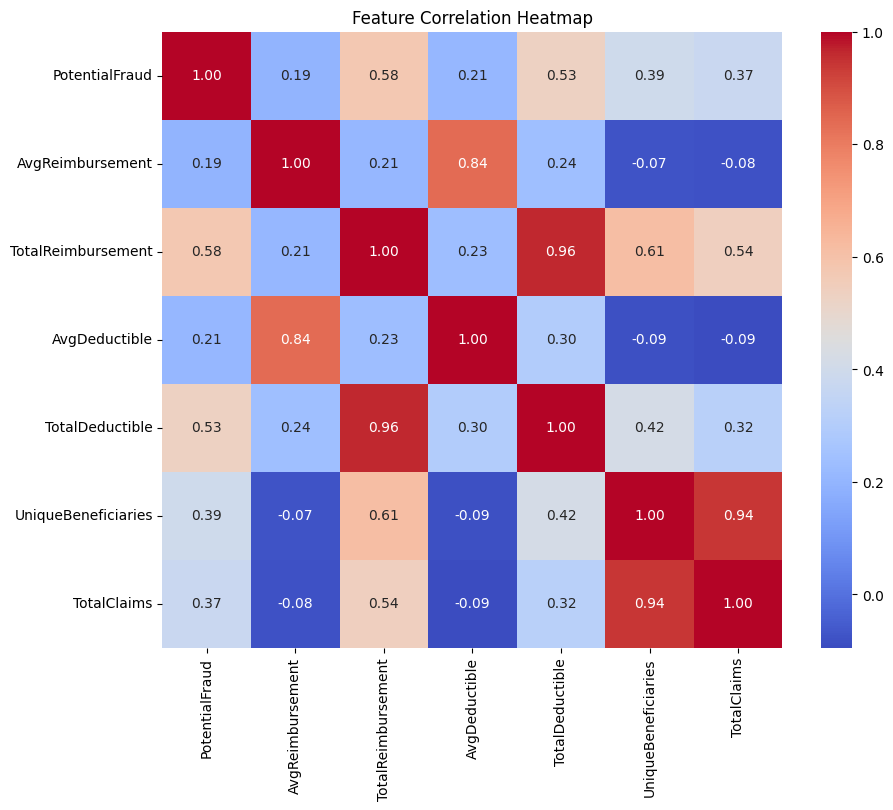

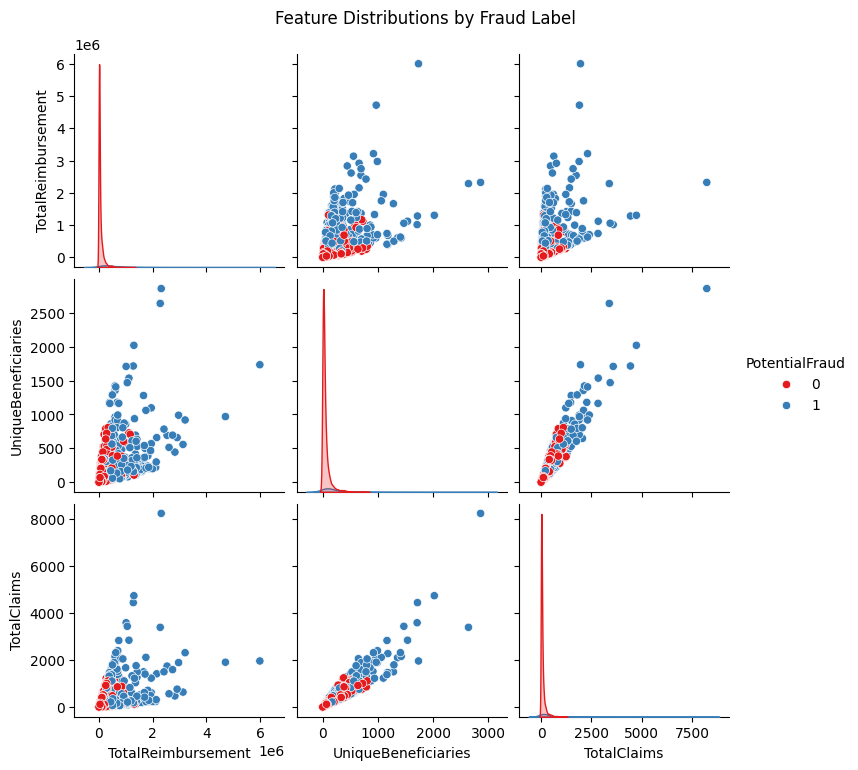

In [4]:
# 1. Display the first few rows of the final dataset
print("--- Final Dataset Header ---")
display(df.head())

# 2. Check data types and non-null counts
print("\n--- Dataset Info ---")
print(df.info())

# 3. Statistical Summary of the Engineered Features
print("\n--- Descriptive Statistics ---")
display(df.describe())

# 4. Check for any missing values after merging
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# 5. Correlation Heatmap
# This shows which features have the strongest relationship with PotentialFraud
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop('Provider', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 6. Pairplot for a subset of features to see class separation
# I will visualize how the 'TotalReimbursement' and 'UniqueBeneficiaries' vary by Fraud status
sns.pairplot(df, vars=['TotalReimbursement', 'UniqueBeneficiaries', 'TotalClaims'],
             hue='PotentialFraud', palette='Set1', diag_kind='kde')
plt.suptitle('Feature Distributions by Fraud Label', y=1.02)
plt.show()

# **Machine Learning Model**

## **Random Forest**
I am training a Random Forest classifier on the original imbalanced data. I will measure the time taken and evaluate it using multiple metrics including Precision, Recall, and the ROC-AUC.

Random Forest (Imbalanced) - Training Time: 1.3647s
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       981
           1       0.68      0.56      0.62       101

    accuracy                           0.93      1082
   macro avg       0.82      0.77      0.79      1082
weighted avg       0.93      0.93      0.93      1082



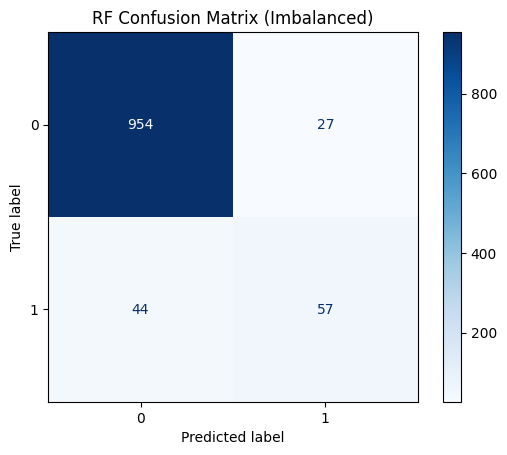

In [5]:
start_time = time.time()
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest (Imbalanced) - Training Time: {rf_train_time:.4f}s")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues')
plt.title('RF Confusion Matrix (Imbalanced)')
plt.show()

## **XGBoost**

XGBoost (Imbalanced) - Training Time: 0.3170s
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       981
           1       0.67      0.52      0.59       101

    accuracy                           0.93      1082
   macro avg       0.81      0.75      0.78      1082
weighted avg       0.93      0.93      0.93      1082



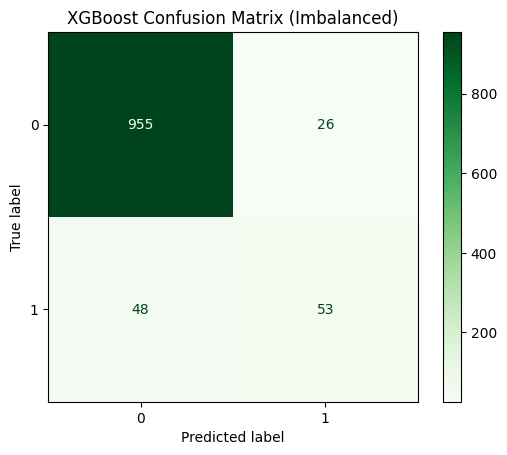

In [6]:
start_time = time.time()
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost (Imbalanced) - Training Time: {xgb_train_time:.4f}s")
print(classification_report(y_test, y_pred_xgb))

ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, cmap='Greens')
plt.title('XGBoost Confusion Matrix (Imbalanced)')
plt.show()

## **LightGBM**

[LightGBM] [Info] Number of positive: 405, number of negative: 3923
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 4328, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.093577 -> initscore=-2.270725
[LightGBM] [Info] Start training from score -2.270725
LightGBM (Imbalanced) - Training Time: 0.1844s
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.73      0.55      0.63       101

    accuracy                           0.94      1082
   macro avg       0.84      0.77      0.80      1082
weighted avg       0.93      0.94      0.94      1082



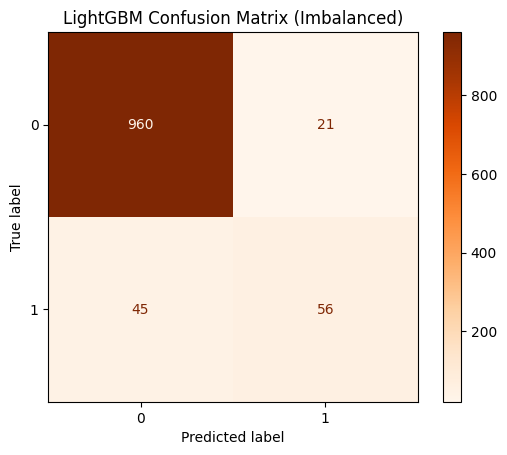

In [7]:
start_time = time.time()
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)
lgbm_train_time = time.time() - start_time

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print(f"LightGBM (Imbalanced) - Training Time: {lgbm_train_time:.4f}s")
print(classification_report(y_test, y_pred_lgbm))

ConfusionMatrixDisplay.from_estimator(lgbm_model, X_test, y_test, cmap='Oranges')
plt.title('LightGBM Confusion Matrix (Imbalanced)')
plt.show()

## **ROC Curve Comparison**
I will plot the ROC curves for all three models to visualize their diagnostic ability before balancing the data.

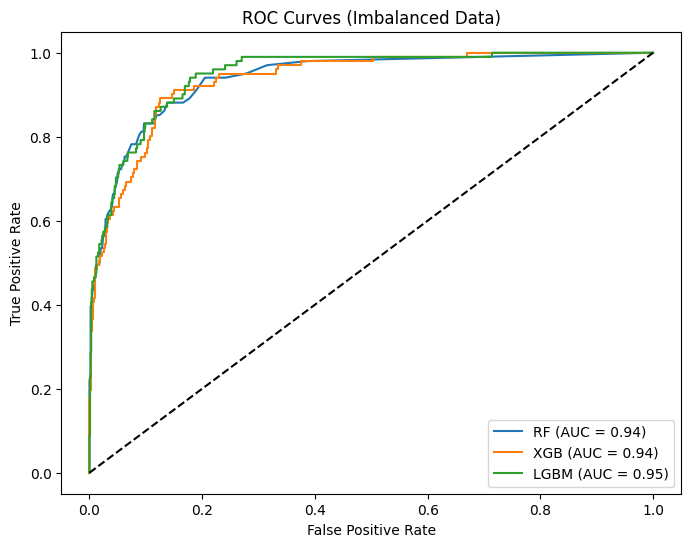

In [8]:
plt.figure(figsize=(8, 6))
for name, prob in [('RF', y_prob_rf), ('XGB', y_prob_xgb), ('LGBM', y_prob_lgbm)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves (Imbalanced Data)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# **Comparison of Models**
I will now aggregate the performance metrics of the Random Forest, XGBoost, and LightGBM models trained on the original imbalanced data. This comparison is crucial for answering RQ1, as it highlights how the models perform when the minority fraud class is underrepresented.

--- Model Performance Comparison (Before SMOTE) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Random Forest,0.9344,0.6786,0.5644,0.6162,0.9398,1.3647
1,XGBoost,0.9316,0.6709,0.5248,0.5889,0.9372,0.3170
2,LightGBM,0.9390,0.7273,0.5545,0.6292,0.9477,0.1844


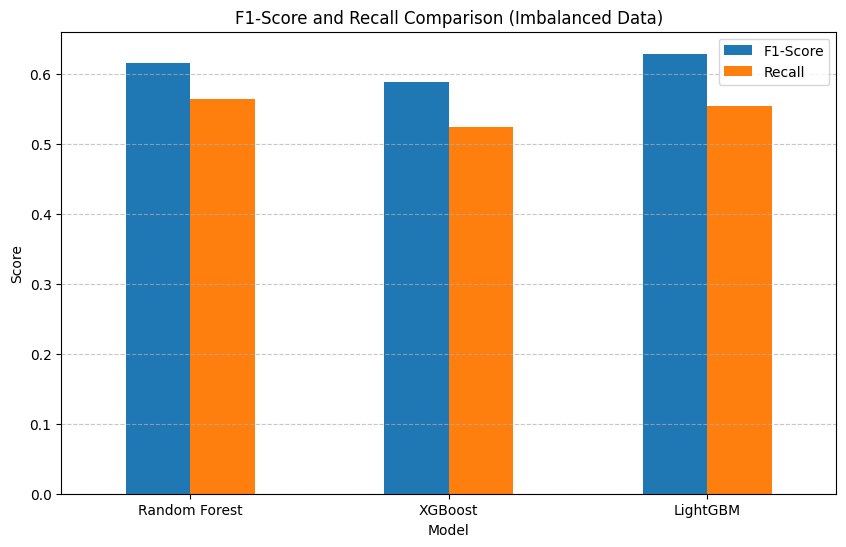

In [9]:
# Create a dictionary to store the metrics for each model
comparison_data = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm)
    ],
    'ROC-AUC': [
        auc(roc_curve(y_test, y_prob_rf)[0], roc_curve(y_test, y_prob_rf)[1]),
        auc(roc_curve(y_test, y_prob_xgb)[0], roc_curve(y_test, y_prob_xgb)[1]),
        auc(roc_curve(y_test, y_prob_lgbm)[0], roc_curve(y_test, y_prob_lgbm)[1])
    ],
    'Training Time (s)': [rf_train_time, xgb_train_time, lgbm_train_time]
}

# Convert to DataFrame for a clean table display
comparison_df = pd.DataFrame(comparison_data)

# Round the values for better readability
comparison_df = comparison_df.round(4)

print("--- Model Performance Comparison (Before SMOTE) ---")
display(comparison_df)

# Visualizing the F1-Score and Recall comparison
comparison_df.set_index('Model')[['F1-Score', 'Recall']].plot(kind='bar', figsize=(10, 6))
plt.title('F1-Score and Recall Comparison (Imbalanced Data)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Addressing Imbalance with SMOTE**
As per my research question (RQ3), I will apply the Synthetic Minority Over-sampling Technique (SMOTE). This will create synthetic samples of the fraudulent class to help the models learn the minority patterns better.

In [10]:


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"New Training Shape: {X_train_res.shape}")
print("Class Distribution After SMOTE:")
print(pd.Series(y_train_res).value_counts())

New Training Shape: (7846, 6)
Class Distribution After SMOTE:
PotentialFraud
0    3923
1    3923
Name: count, dtype: int64


# **Model Tranning after Smote**

--- Random Forest (After SMOTE) ---
Training Time: 1.9160s
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       981
           1       0.47      0.77      0.58       101

    accuracy                           0.90      1082
   macro avg       0.72      0.84      0.76      1082
weighted avg       0.93      0.90      0.91      1082



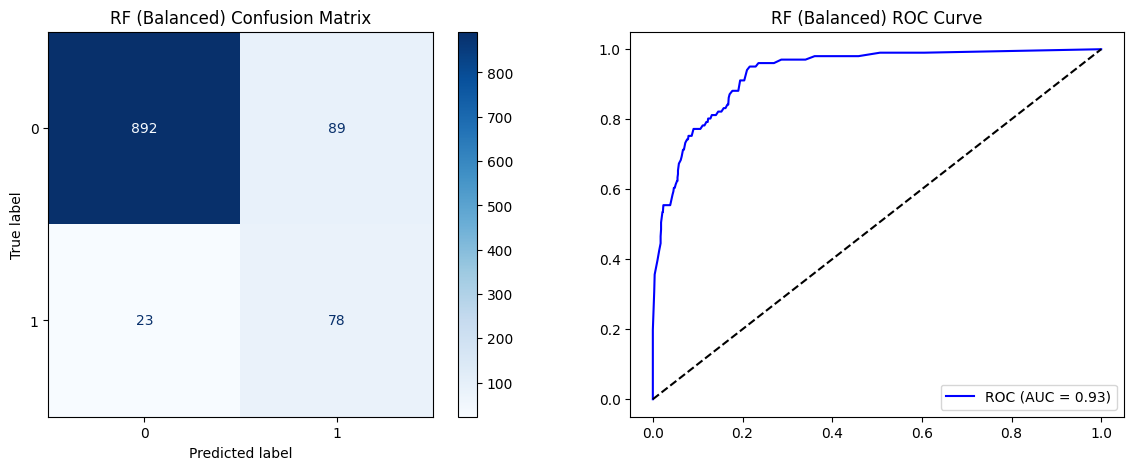

In [11]:
# Training
start_time = time.time()
rf_bal = RandomForestClassifier(random_state=42)
rf_bal.fit(X_train_res, y_train_res)
rf_bal_time = time.time() - start_time

# Predictions
y_pred_rf_b = rf_bal.predict(X_test)
y_prob_rf_b = rf_bal.predict_proba(X_test)[:, 1]

# Evaluation
print("--- Random Forest (After SMOTE) ---")
print(f"Training Time: {rf_bal_time:.4f}s")
print(classification_report(y_test, y_pred_rf_b))

# Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_b, ax=ax[0], cmap='Blues')
ax[0].set_title('RF (Balanced) Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf_b)
ax[1].plot(fpr, tpr, color='blue', label=f'ROC (AUC = {auc(fpr, tpr):.2f})')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('RF (Balanced) ROC Curve')
ax[1].legend()
plt.show()

--- XGBoost (After SMOTE) ---
Training Time: 0.1844s
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       981
           1       0.45      0.71      0.55       101

    accuracy                           0.89      1082
   macro avg       0.71      0.81      0.74      1082
weighted avg       0.92      0.89      0.90      1082



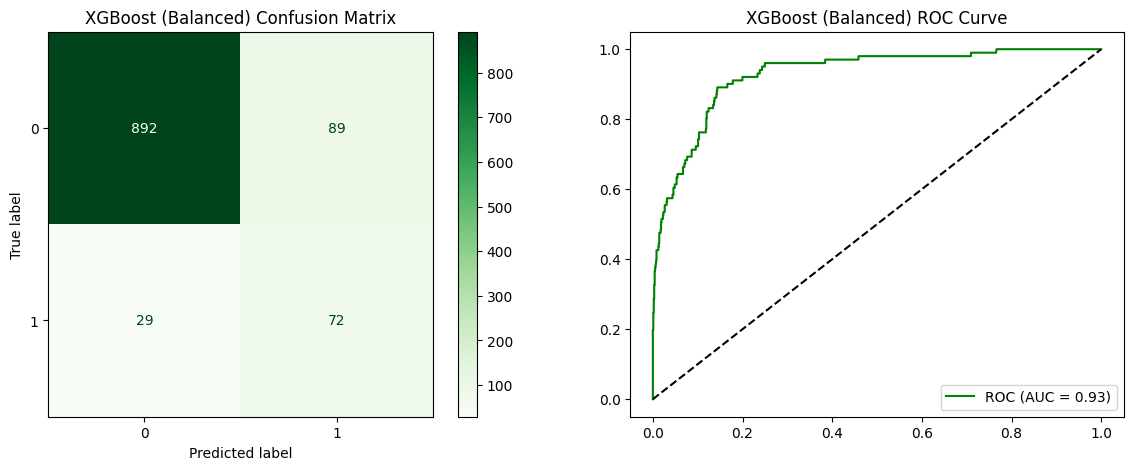

In [12]:
# Training
start_time = time.time()
xgb_bal = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_bal.fit(X_train_res, y_train_res)
xgb_bal_time = time.time() - start_time

# Predictions
y_pred_xgb_b = xgb_bal.predict(X_test)
y_prob_xgb_b = xgb_bal.predict_proba(X_test)[:, 1]

# Evaluation
print("--- XGBoost (After SMOTE) ---")
print(f"Training Time: {xgb_bal_time:.4f}s")
print(classification_report(y_test, y_pred_xgb_b))

# Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_b, ax=ax[0], cmap='Greens')
ax[0].set_title('XGBoost (Balanced) Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb_b)
ax[1].plot(fpr, tpr, color='green', label=f'ROC (AUC = {auc(fpr, tpr):.2f})')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('XGBoost (Balanced) ROC Curve')
ax[1].legend()
plt.show()

[LightGBM] [Info] Number of positive: 3923, number of negative: 3923
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 7846, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--- LightGBM (After SMOTE) ---
Training Time: 0.1465s
              precision    recall  f1-score   support

           0       0.97      0.90      0.94       981
           1       0.45      0.77      0.57       101

    accuracy                           0.89      1082
   macro avg       0.71      0.84      0.75      1082
weighted avg       0.93      0.89      0.90      1082



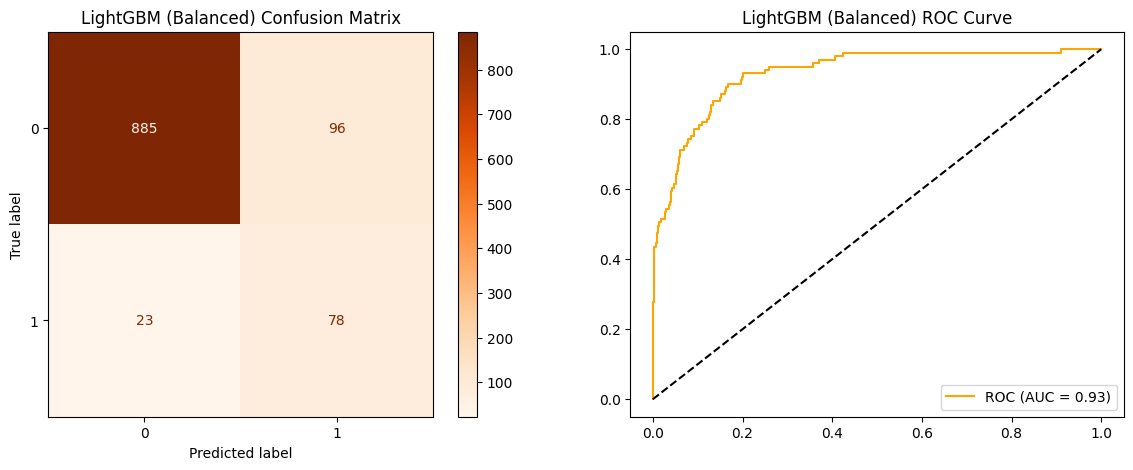

In [13]:
# Training
start_time = time.time()
lgbm_bal = LGBMClassifier(random_state=42)
lgbm_bal.fit(X_train_res, y_train_res)
lgbm_bal_time = time.time() - start_time

# Predictions
y_pred_lgbm_b = lgbm_bal.predict(X_test)
y_prob_lgbm_b = lgbm_bal.predict_proba(X_test)[:, 1]

# Evaluation
print("--- LightGBM (After SMOTE) ---")
print(f"Training Time: {lgbm_bal_time:.4f}s")
print(classification_report(y_test, y_pred_lgbm_b))

# Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm_b, ax=ax[0], cmap='Oranges')
ax[0].set_title('LightGBM (Balanced) Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lgbm_b)
ax[1].plot(fpr, tpr, color='orange', label=f'ROC (AUC = {auc(fpr, tpr):.2f})')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('LightGBM (Balanced) ROC Curve')
ax[1].legend()
plt.show()

--- Model Performance Comparison (After SMOTE) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Random Forest (SMOTE),0.8965,0.4671,0.7723,0.5821,0.9322,1.9160
1,XGBoost (SMOTE),0.8909,0.4472,0.7129,0.5496,0.9280,0.1844
2,LightGBM (SMOTE),0.8900,0.4483,0.7723,0.5673,0.9316,0.1465


/tmp/ipykernel_168/3958425607.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Recall', data=bal_comparison_df, palette='viridis')


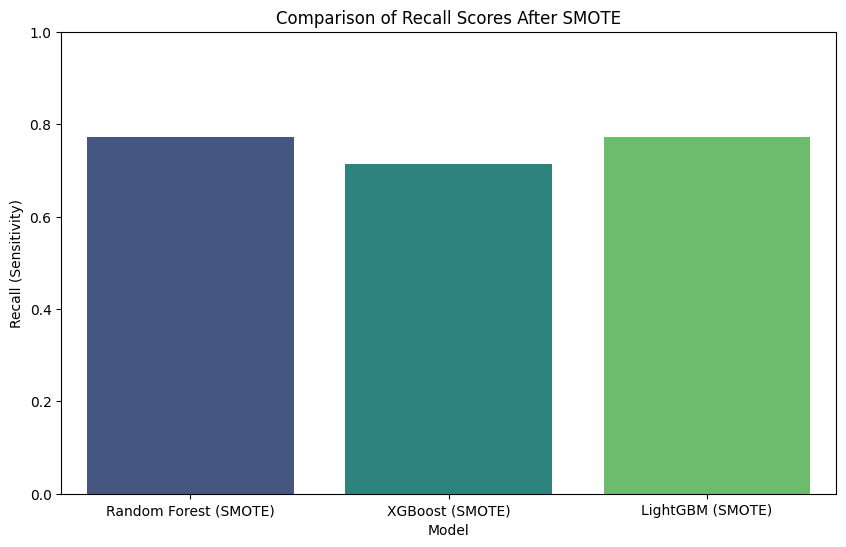

In [14]:
# Compile metrics into a dictionary
bal_comparison_data = {
    'Model': ['Random Forest (SMOTE)', 'XGBoost (SMOTE)', 'LightGBM (SMOTE)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf_b),
        accuracy_score(y_test, y_pred_xgb_b),
        accuracy_score(y_test, y_pred_lgbm_b)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf_b),
        precision_score(y_test, y_pred_xgb_b),
        precision_score(y_test, y_pred_lgbm_b)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf_b),
        recall_score(y_test, y_pred_xgb_b),
        recall_score(y_test, y_pred_lgbm_b)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf_b),
        f1_score(y_test, y_pred_xgb_b),
        f1_score(y_test, y_pred_lgbm_b)
    ],
    'ROC-AUC': [
        auc(roc_curve(y_test, y_prob_rf_b)[0], roc_curve(y_test, y_prob_rf_b)[1]),
        auc(roc_curve(y_test, y_prob_xgb_b)[0], roc_curve(y_test, y_prob_xgb_b)[1]),
        auc(roc_curve(y_test, y_prob_lgbm_b)[0], roc_curve(y_test, y_prob_lgbm_b)[1])
    ],
    'Training Time (s)': [rf_bal_time, xgb_bal_time, lgbm_bal_time]
}

# Create DataFrame
bal_comparison_df = pd.DataFrame(bal_comparison_data).round(4)

print("--- Model Performance Comparison (After SMOTE) ---")
display(bal_comparison_df)

# Final Visualization: Comparative Recall Improvement
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Recall', data=bal_comparison_df, palette='viridis')
plt.title('Comparison of Recall Scores After SMOTE')
plt.ylabel('Recall (Sensitivity)')
plt.ylim(0, 1)
plt.show()

# **Cross-Validation Strategy**
I will use Stratified 5-Fold Cross-Validation. This means the data is split into 5 parts, and for each iteration, 4 parts are used for training and 1 part for testing. I will calculate the Mean and Standard Deviation for Accuracy, Precision, Recall, and F1-Score. A low standard deviation will indicate that my model is stable and generalizes well to unseen data.

In [15]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize the CV strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metrics to track
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 1. Random Forest Cross-Validation
print("Running Cross-Validation for Random Forest...")
rf_cv_results = cross_validate(rf_bal, X_train_res, y_train_res, cv=skf, scoring=scoring)

# Extract means and stds
rf_cv_mean = {metric: np.mean(rf_cv_results[f'test_{metric}']) for metric in scoring}
rf_cv_std = {metric: np.std(rf_cv_results[f'test_{metric}']) for metric in scoring}

print("Random Forest CV Completed.")

Running Cross-Validation for Random Forest...
Random Forest CV Completed.


In [16]:
# 2. XGBoost Cross-Validation
print("Running Cross-Validation for XGBoost...")
xgb_cv_results = cross_validate(xgb_bal, X_train_res, y_train_res, cv=skf, scoring=scoring)

# Extract means and stds
xgb_cv_mean = {metric: np.mean(xgb_cv_results[f'test_{metric}']) for metric in scoring}
xgb_cv_std = {metric: np.std(xgb_cv_results[f'test_{metric}']) for metric in scoring}

print("XGBoost CV Completed.")

Running Cross-Validation for XGBoost...
XGBoost CV Completed.


In [17]:
# 3. LightGBM Cross-Validation
print("Running Cross-Validation for LightGBM...")
lgbm_cv_results = cross_validate(lgbm_bal, X_train_res, y_train_res, cv=skf, scoring=scoring)

# Extract means and stds
lgbm_cv_mean = {metric: np.mean(lgbm_cv_results[f'test_{metric}']) for metric in scoring}
lgbm_cv_std = {metric: np.std(lgbm_cv_results[f'test_{metric}']) for metric in scoring}

print("LightGBM CV Completed.")

Running Cross-Validation for LightGBM...
[LightGBM] [Info] Number of positive: 3138, number of negative: 3138
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 6276, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3139, number of negative: 3138
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 6277, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500080 -> initscore=0.000319
[LightGBM] [Info] Start training from score 0.000319
[LightGBM] [Info] Number of positive

In [18]:
# Create the comparison table
cv_summary_data = {
    'Model': ['Random Forest (SMOTE)', 'XGBoost (SMOTE)', 'LightGBM (SMOTE)'],
    'Accuracy (Mean ± Std)': [
        f"{rf_cv_mean['accuracy']:.4f} ± {rf_cv_std['accuracy']:.4f}",
        f"{xgb_cv_mean['accuracy']:.4f} ± {xgb_cv_std['accuracy']:.4f}",
        f"{lgbm_cv_mean['accuracy']:.4f} ± {lgbm_cv_std['accuracy']:.4f}"
    ],
    'Precision (Mean ± Std)': [
        f"{rf_cv_mean['precision']:.4f} ± {rf_cv_std['precision']:.4f}",
        f"{xgb_cv_mean['precision']:.4f} ± {xgb_cv_std['precision']:.4f}",
        f"{lgbm_cv_mean['precision']:.4f} ± {lgbm_cv_std['precision']:.4f}"
    ],
    'Recall (Mean ± Std)': [
        f"{rf_cv_mean['recall']:.4f} ± {rf_cv_std['recall']:.4f}",
        f"{xgb_cv_mean['recall']:.4f} ± {xgb_cv_std['recall']:.4f}",
        f"{lgbm_cv_mean['recall']:.4f} ± {lgbm_cv_std['recall']:.4f}"
    ],
    'F1-Score (Mean ± Std)': [
        f"{rf_cv_mean['f1']:.4f} ± {rf_cv_std['f1']:.4f}",
        f"{xgb_cv_mean['f1']:.4f} ± {xgb_cv_std['f1']:.4f}",
        f"{lgbm_cv_mean['f1']:.4f} ± {lgbm_cv_std['f1']:.4f}"
    ]
}

# Create DataFrame
cv_summary_df = pd.DataFrame(cv_summary_data)

print("--- 5-Fold Cross-Validation Performance Summary ---")
display(cv_summary_df)

--- 5-Fold Cross-Validation Performance Summary ---


,Model,Accuracy (Mean ± Std),Precision (Mean ± Std),Recall (Mean ± Std),F1-Score (Mean ± Std)
0,Random Forest (SMOTE),0.9335 ± 0.0042,0.9196 ± 0.0060,0.9500 ± 0.0053,0.9346 ± 0.0041
1,XGBoost (SMOTE),0.9324 ± 0.0088,0.9209 ± 0.0066,0.9462 ± 0.0152,0.9333 ± 0.0091
2,LightGBM (SMOTE),0.9285 ± 0.0038,0.9154 ± 0.0080,0.9444 ± 0.0041,0.9296 ± 0.0034


# **Explainable AI (XAI) using SHAP**
In this section, I will use SHAP values to interpret the LightGBM model (or the best-performing model). This fulfills the requirement of my second research question by identifying which derived features are the most influential in flagging a provider as potentially fraudulent. This moves the model from being a "black box" to a transparent system.

In [19]:
# Install SHAP if not already available
!pip install shap

import shap

# I will use the balanced LightGBM model for explanation as it showed strong performance
explainer = shap.TreeExplainer(lgbm_bal)

# Calculate SHAP values for the test set
# This might take a moment depending on the size of the data
shap_values = explainer.shap_values(X_test)

# In LightGBM, shap_values can be a list (one for each class).
# We take the values for the 'Fraud' class (index 1).
if isinstance(shap_values, list):
    shap_val_to_plot = shap_values[1]
else:
    shap_val_to_plot = shap_values

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## **Global Interpretability: Feature Importance**
I will now plot the Summary Plot. This plot ranks features by their importance and shows how the value of a feature (high or low) influences the prediction. For example, it will reveal if a "High Total Reimbursement" is the primary driver for a "Fraud" classification.

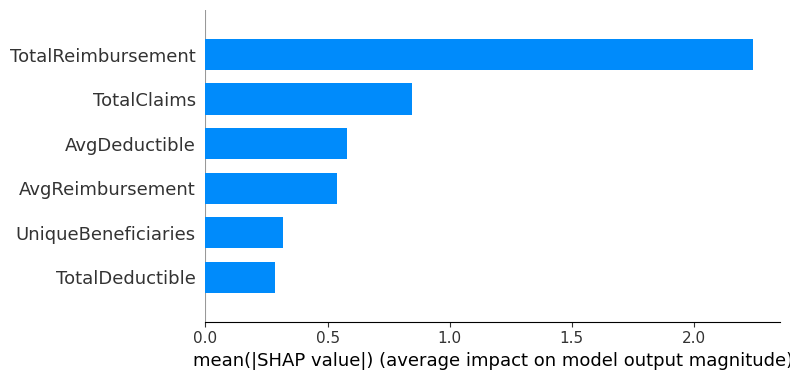

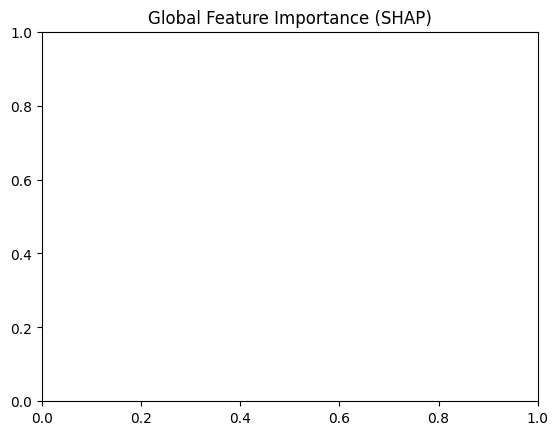

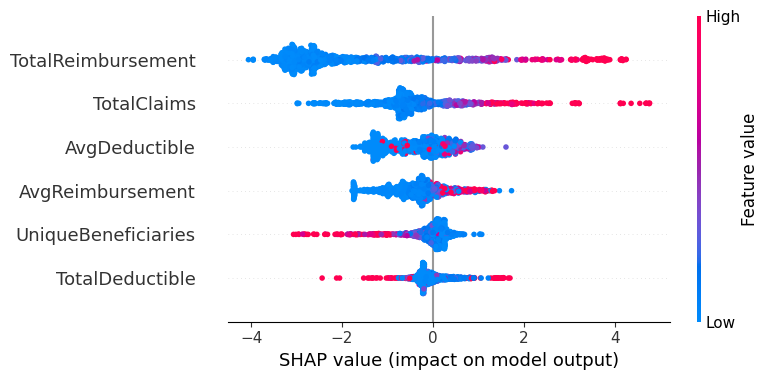

In [20]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_val_to_plot, X_test, plot_type="bar")
plt.title("Global Feature Importance (SHAP)")
plt.show()

# Detailed Summary Plot (Beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_val_to_plot, X_test)
plt.show()

## **Local Interpretability: explaining a Single Prediction**
To demonstrate how the model works on an individual case, I will create a Force Plot. This shows how different features "pushed" the model's prediction toward Fraud or Non-Fraud for one specific provider.

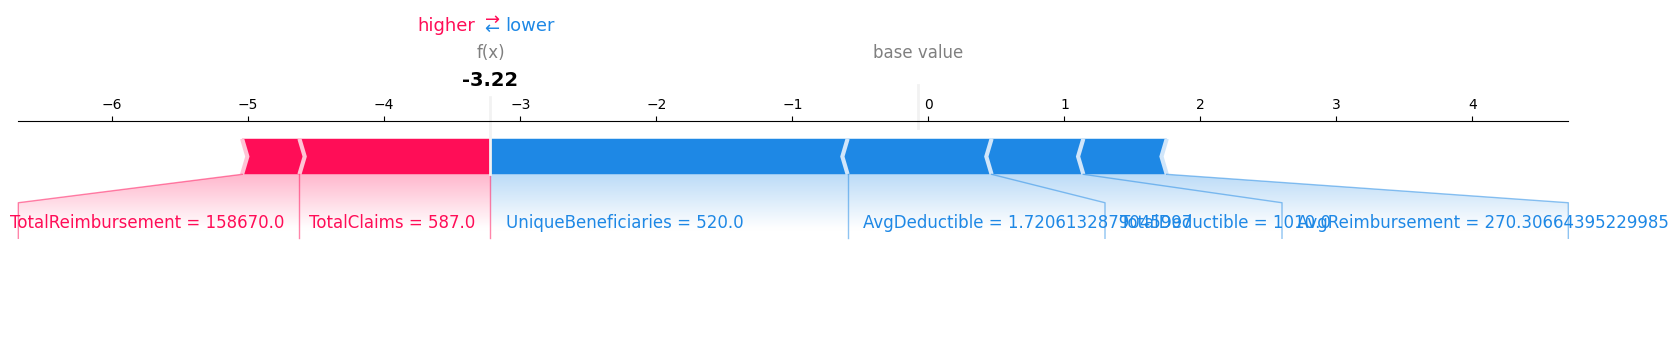

In [21]:
# Initialize JS for SHAP visualization
shap.initjs()

# Choose a specific instance (e.g., the first row of the test set)
instance_index = 0

# Generate the Force Plot
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
    shap_val_to_plot[instance_index, :],
    X_test.iloc[instance_index, :],
    matplotlib=True
)
plt.show()